## 1. CARGA DOS DADOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho absoluto do seu arquivo no Windows
path = r"C:\Users\eulle\OneDrive\Documentos\Projetos\Credit Risk\data\credit_risk_dataset.csv"

# Carregar o dataset
df = pd.read_csv(path)
print(f"Formato do dataset original: {df.shape}")
df.head()

Formato do dataset original: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. TRATAMENTO DE OUTLIERS E MAPEAMENTO DE NULOS

In [2]:
# 1. Filtrar idades realistas
df_cleaned = df[df['person_age'] < 100].copy()

# 2. Filtrar tempo de emprego realista (mantendo os valores nulos por enquanto)
df_cleaned = df_cleaned[(df_cleaned['person_emp_length'] < 60) | (df_cleaned['person_emp_length'].isnull())]
print(f"Formato após remoção de outliers drásticos: {df_cleaned.shape}")

# 3. Mapear o percentual de dados faltantes
print("\n--- Percentual de Dados Faltantes por Coluna ---")
print(df_cleaned.isnull().mean() * 100)

Formato após remoção de outliers drásticos: (32574, 12)

--- Percentual de Dados Faltantes por Coluna ---
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747590
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.562842
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


## 3. DIVISÃO EM TREINO E TESTE

In [3]:
from sklearn.model_selection import train_test_split

# 1. Separar as variáveis explicativas (X) da variável alvo (y)
X = df_cleaned.drop(columns=['loan_status'])
y = df_cleaned['loan_status']

# 2. Dividir em treino (80%) e teste (20%) garantindo a mesma proporção da variável alvo (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do X_train: {X_train.shape}")
print(f"Tamanho do X_test: {X_test.shape}")
print(f"\nProporção de inadimplência no Treino:\n{y_train.value_counts(normalize=True)}")

Tamanho do X_train: (26059, 11)
Tamanho do X_test: (6515, 11)

Proporção de inadimplência no Treino:
loan_status
0    0.781803
1    0.218197
Name: proportion, dtype: float64


## 4. CONSTRUÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Separar as colunas por tipo de dado
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Colunas numéricas: {num_features}")
print(f"Colunas categóricas: {cat_features}")

# 2. Criar o pipeline para os dados numéricos (Trata nulos + Escala os dados)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Criar o pipeline para os dados categóricos (Transforma texto em colunas binárias)
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Juntar ambos os tratamentos mapeados por coluna
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 5. Ajustar o pré-processador nos dados de treino e transformar para validar
X_train_processed = preprocessor.fit_transform(X_train)
print(f"\nFormato do X_train após o pré-processamento: {X_train_processed.shape}")

Colunas numéricas: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Colunas categóricas: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Formato do X_train após o pré-processamento: (26059, 26)


C:\Users\eulle\AppData\Local\Temp\ipykernel_34488\2739248330.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include=['object']).columns.tolist()


## 5. TREINAMENTO DO MODELO (XGBOOST)

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Definir o pipeline final (Pré-processamento + Modelo)
# Usaremos 'scale_pos_weight' para ajudar o modelo a lidar com o desbalanceamento das classes
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, scale_pos_weight=3))
])

# 2. Treinar o modelo
model.fit(X_train, y_train)

# 3. Fazer previsões no teste
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 4. Avaliação
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5094
           1       0.85      0.79      0.82      1421

    accuracy                           0.92      6515
   macro avg       0.90      0.87      0.88      6515
weighted avg       0.92      0.92      0.92      6515

ROC AUC Score: 0.9481


## 6. EXPORTAÇÃO DO MODELO TREINADO

In [6]:
import joblib
import os

# 1. Criar a pasta 'models' se ela não existir
os.makedirs('models', exist_ok=True)

# 2. Salvar o pipeline completo (Pré-processador + XGBoost) em um arquivo
model_path = 'models/credit_risk_model.joblib'
joblib.dump(model, model_path)

print(f"Sucesso! O pipeline completo foi salvo em: {model_path}")

Sucesso! O pipeline completo foi salvo em: models/credit_risk_model.joblib


## 7. FEATURE IMPORTANCE

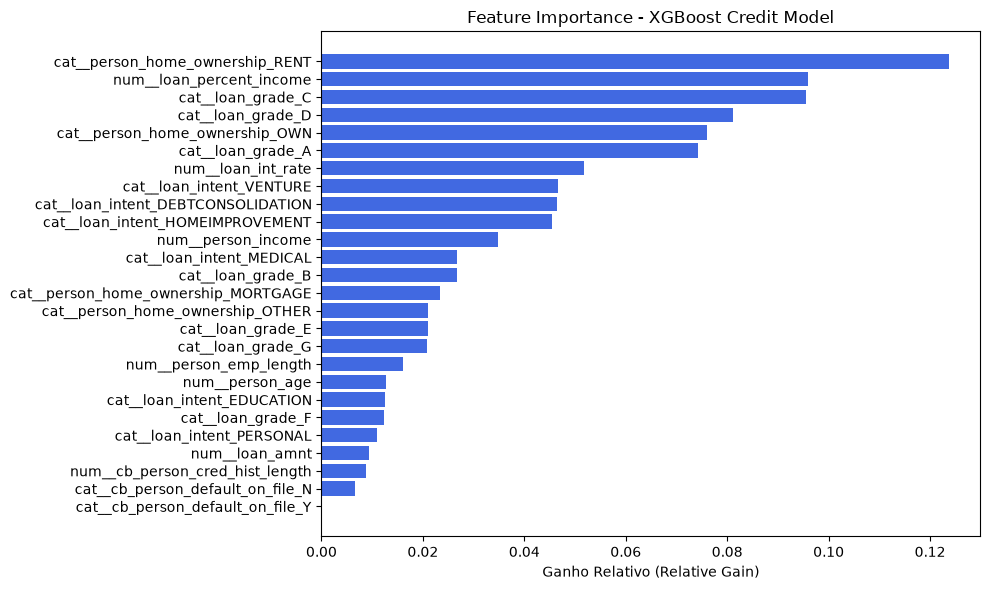

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrai os nomes das colunas geradas após o pré-processamento do Pipeline
feature_names = model[:-1].get_feature_names_out()

# 2. Acessa o último passo do seu Pipeline (o XGBoost de fato) para pegar a importância
importances = model[-1].feature_importances_

# 3. Cria o DataFrame ordenado para o gráfico
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 4. Plota o gráfico de barras horizontais
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='royalblue')
plt.xlabel('Ganho Relativo (Relative Gain)')
plt.title('Feature Importance - XGBoost Credit Model')
plt.tight_layout()

plt.savefig('image_f305f4.png', dpi=300, bbox_inches='tight')

plt.show()


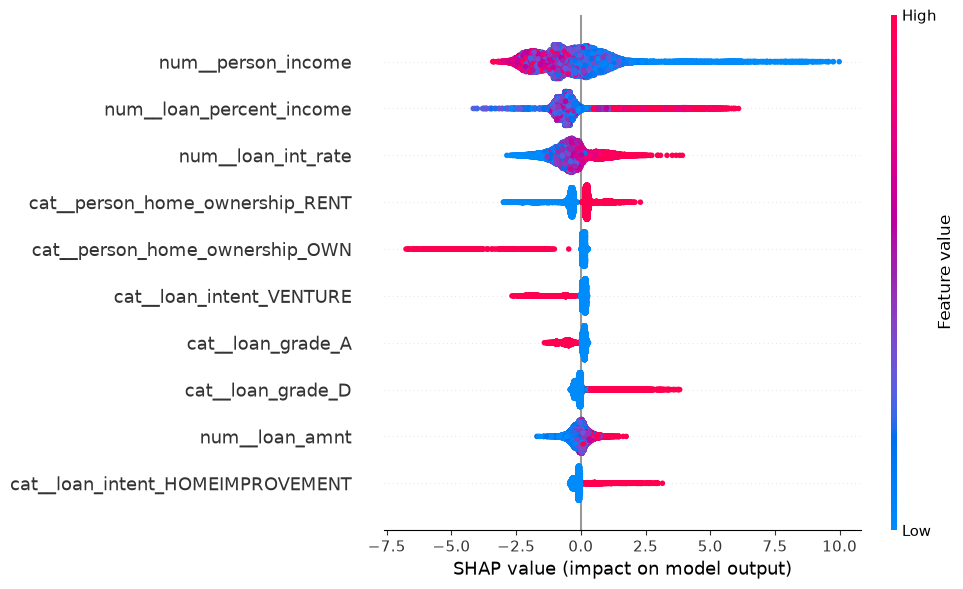

In [11]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 2. Extrai o modelo XGBoost de dentro do seu pipeline
xgb_model = model[-1]

# 3. Transforma os dados de treino usando apenas a parte de pré-processamento do pipeline
X_train_transformed = model[:-1].transform(X_train)

# Se o resultado for uma matriz esparsa, converte para DataFrame com os nomes corretos das colunas
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

feature_names = model[:-1].get_feature_names_out()
X_df = pd.DataFrame(X_train_transformed, columns=feature_names)

# 4. Cria o explicador do SHAP focado em modelos de árvore (TreeExplainer)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_df)

# 5. Plota o Summary Plot 
shap.summary_plot(shap_values, X_df, max_display=10, plot_size=(10, 6), show=False)

plt.savefig('shap.png', dpi=300, bbox_inches='tight')
plt.show()